In [1]:
from astroML.datasets import generate_mu_z
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from scipy.optimize import fmin_cobyla
import numpy as np
import astropy
from astropy.visualization import hist
from sklearn.neighbors import KernelDensity

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
C:\Users\User\AppData\Local\Temp\ipykernel_23708\224906477.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


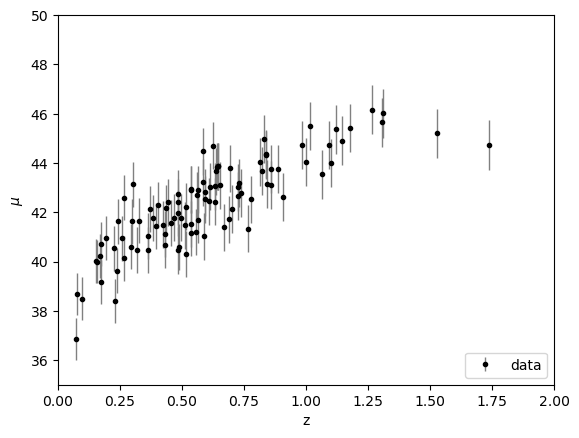

In [3]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [5]:
X_grid = np.linspace(0, 2, 100).reshape(-1,1)
z_fit = z_sample[:, None]

In [7]:
kernel1 = ConstantKernel(1, (1e-1, 1e1))* kernels.RBF(length_scale = 10.0, length_scale_bounds = (1e-2, 1e2))
gp1 = GaussianProcessRegressor(kernel=kernel1, alpha= dmu**2)
gp1.fit(z_fit, mu_sample)
mu_predict, sigma_predict = gp1.predict(X_grid, return_std=True) 

C:\Users\User\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


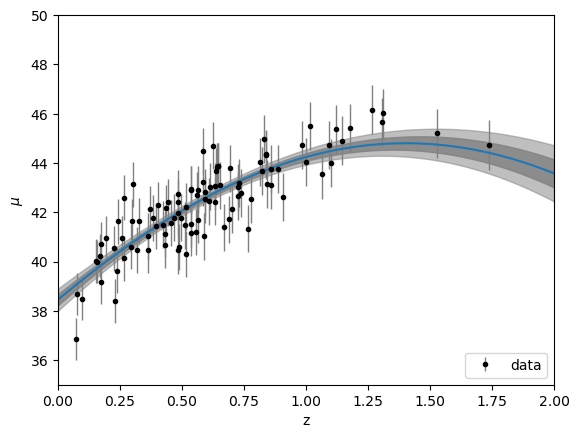

In [9]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(X_grid, mu_predict)
plt.xlabel(r"z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

upper1 = mu_predict + sigma_predict
lower1 = mu_predict - sigma_predict
upper2 = mu_predict + 2*sigma_predict
lower2 = mu_predict - 2*sigma_predict
plt.fill_between(np.linspace(0, 2, 100), lower2, upper2,color="grey", alpha=0.5)
plt.fill_between(np.linspace(0, 2, 100), lower1, upper1,color="grey", alpha=0.8)

In [11]:
#function 
def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(X_grid) # sklearn returns log(density)
    return np.exp(log_pdf)

def cloned_data(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_fit = kde_skl.fit(data[:, np.newaxis])
    cloned = kde_fit.sample(1000) #ten times more 
    return cloned

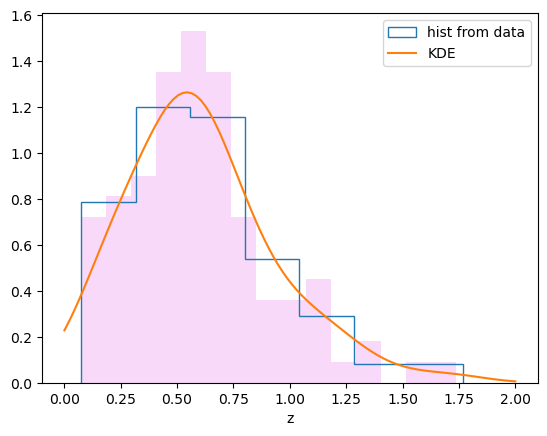

In [13]:
astropy.visualization.hist(z_sample, bins="scott", histtype="step",density=True, label="hist from data")
plt.hist(z_sample,bins=15, alpha=0.30, color="violet", density=True) 

PDF_z = kde_sklearn(z_sample,bandwidth=0.15,kernel="gaussian")
plt.plot(X_grid,PDF_z, label="KDE") 
plt.xlabel("z")
plt.legend()

In [15]:
#print(PDF_z)
z_cloned = cloned_data(z_sample,bandwidth=0.15,kernel="gaussian")
print(len(z_cloned))
#print(z_cloned)

1000


(array([0.04724471, 0.14960824, 0.3543353 , 0.67717414, 1.00788709,
        1.07875415, 1.22836239, 0.95276826, 0.77166355, 0.59843296,
        0.31496472, 0.3070906 , 0.13386   , 0.0866153 , 0.09448941,
        0.03937059, 0.02362235, 0.00787412]),
 array([-0.26599406, -0.13899571, -0.01199736,  0.11500099,  0.24199935,
         0.3689977 ,  0.49599605,  0.62299441,  0.74999276,  0.87699111,
         1.00398946,  1.13098782,  1.25798617,  1.38498452,  1.51198287,
         1.63898123,  1.76597958,  1.89297793,  2.01997629]),
 [<matplotlib.patches.Polygon at 0x27bc1940830>])

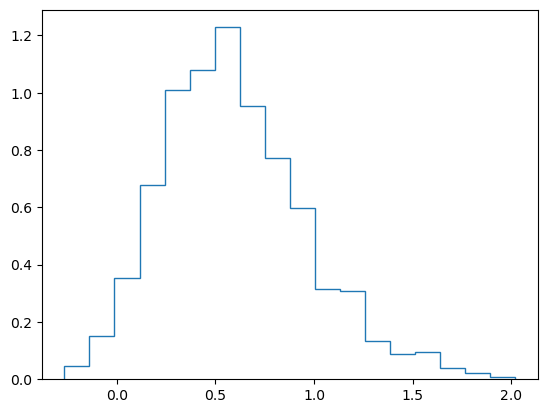

In [17]:
astropy.visualization.hist(z_cloned, bins="scott", histtype="step",density=True, label="hist from data")

In [19]:
kernel2 = ConstantKernel(1, (1e-1, 1e1))* kernels.RBF(length_scale = 10.0, length_scale_bounds = (1e-2, 1e2))
gp2 = GaussianProcessRegressor(kernel=kernel2, alpha= dmu**2)
gp2.fit(z_sample.reshape(-1,1), mu_sample)
mu_pred, sigma_pred = gp2.predict(z_cloned.reshape(-1,1), return_std=True) 

C:\Users\User\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\User\AppData\Local\Temp\ipykernel_23708\3373382237.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


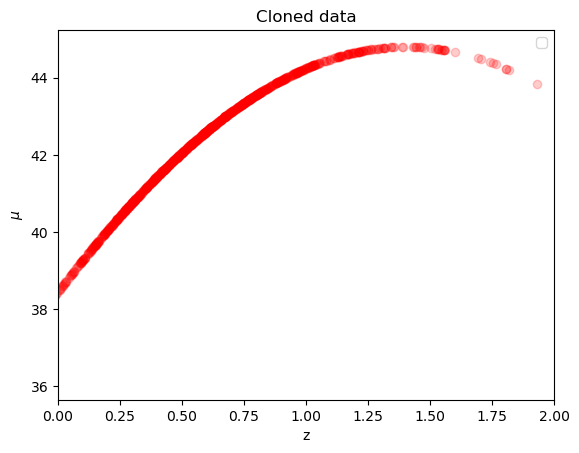

In [21]:
plt.scatter(z_cloned, mu_pred, alpha=0.2, color="red")
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.title("Cloned data")
plt.xlim(0,2)
plt.legend()